In [21]:
import pandas as pd
import numpy as np
import seaborn as sn
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
data = pd.read_csv("dataset.csv")
data

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,ASUS,ASUS Pro ZWL,2023,Windows,Mainstream,Intel,Intel i7-13721,4,12,24,2.6,3.7,AMD,RX 7000 70,3,8,32,HDD,2048,1,LED,14.0,1920x1080,144,90,180,0,Wi-Fi 6,5.1,1.87,24,1712.99
99996,Laptop,Lenovo,Lenovo Stealth 014,2018,Windows,Ultrabook,AMD,AMD Ryzen 5 5117,2,8,16,2.2,3.2,AMD,RX 6000 50,1,4,8,HDD,1024,1,LED,14.0,2560x1600,90,50,65,0,Wi-Fi 6,5.1,1.37,12,1258.99
99997,Laptop,ASUS,ASUS Zen LKD,2020,Windows,Mainstream,Intel,Intel i5-12677,2,6,10,2.2,3.2,NVIDIA,RTX 20 60,2,6,16,NVMe,1024,1,OLED,14.0,2560x1600,120,99,180,0,Wi-Fi 6,4.2,1.17,12,1686.99
99998,Laptop,ASUS,ASUS Blade DH6,2020,Windows,Mainstream,AMD,AMD Ryzen 7 4590,4,12,24,2.6,3.5,NVIDIA,RTX 30 70,3,8,32,NVMe,256,1,OLED,15.6,2560x1600,120,60,90,0,Wi-Fi 6,5.3,1.70,24,2164.99


In [36]:
data.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,903.936000,1.524980,20.126655,98.464860,41.813470,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,774.243654,0.797284,6.709577,43.301652,35.868841,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,256.000000,1.000000,13.300000,60.000000,0.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,512.000000,1.000000,14.000000,60.000000,0.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,512.000000,1.000000,16.000000,90.000000,56.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,1024.000000,2.000000,27.000000,120.000000,70.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,4096.000000,4.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

In [38]:
data.columns

Index(['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor',
       'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads',
       'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier',
       'vram_gb', 'ram_gb', 'storage_type', 'storage_gb',
       'storage_drive_count', 'display_type', 'display_size_in', 'resolution',
       'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi',
       'bluetooth', 'weight_kg', 'warranty_months', 'price'],
      dtype='object')

[cpu_cores, cpu_threads, cpu_base_ghz]
[display_size_in, resolution, refresh_hz]
[battery_wh, charger_watts, psu_watts]

In [39]:
data["form_factor"].value_counts()

form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192
Name: count, dtype: int64

In [40]:
data["cpu_brand"].value_counts()

cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype: int64

In [41]:
data["brand"].value_counts()

brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64

### Radar chart of performance attributes

[cpu_cores, cpu_threads, cpu_base_ghz] <br>
[display_size_in, resolution, refresh_hz] <br>
[battery_wh, charger_watts, psu_watts]

In [9]:
# Standardize dataset
features = ["cpu_cores", "cpu_threads", "cpu_base_ghz"]
sc = StandardScaler()
scaled = sc.fit_transform(data[features])
scaled_df = pd.DataFrame(scaled, columns=(features))
scaled_df

,cpu_cores,cpu_threads,cpu_base_ghz
0,0.294259,0.476139,0.620265
1,0.294259,0.476139,0.025794
2,-0.498752,-0.347044,0.025794
3,-0.895258,-0.758635,0.025794
4,1.087269,1.299322,0.620265
...,...,...,...
99995,0.294259,0.476139,0.025794
99996,-0.498752,-0.347044,-1.163148
99997,-0.895258,-0.964431,-1.163148
99998,0.294259,0.476139,0.025794


In [20]:
form_factor = "Mainstream"
processed_ds = scaled_df[data["form_factor"] == form_factor]
# Calculate cpu
avg_cpu_cores = processed_ds["cpu_cores"].mean()
avg_cpu_threads = processed_ds["cpu_threads"].mean()
avg_cpu_ghz = processed_ds["cpu_base_ghz"].mean()
spec = pd.DataFrame(dict(
    r=[avg_cpu_cores, avg_cpu_threads, avg_cpu_ghz],
    theta=["cpu_cores", "cpu_threads", "cpu_base_ghz"]
))

px.line_polar(spec, r='r', theta='theta', line_close=True)
# avg_cpu_threads
print(avg_cpu_cores)
print(avg_cpu_threads)
print(avg_cpu_ghz)



-0.026857642072304615
-0.025339820024714466
-0.4738632451445061


<Axes: xlabel='cpu_tier', ylabel='count'>

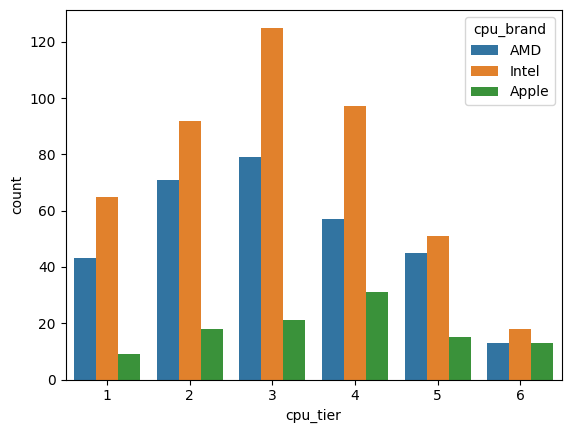

In [116]:
form_factor = "Mainstream"
processed_ds_wo_scale = data[data["form_factor"] == form_factor]
processed_ds_wo_scale = processed_ds_wo_scale[processed_ds_wo_scale["release_year"] < 2019]
sn.countplot(data = processed_ds_wo_scale, x = "cpu_tier", hue="cpu_brand")

<Axes: xlabel='release_year', ylabel='price'>

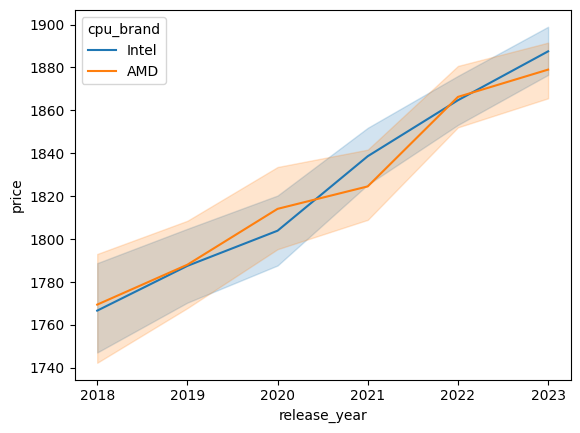

In [117]:
form_factor = "Mainstream"
# processed_ds_wo_scale = data[data["form_factor"] == form_factor]
processed_ds_wo_scale = data[data["cpu_brand"] != "Apple"]
processed_ds_wo_scale = processed_ds_wo_scale[processed_ds_wo_scale["release_year"] < 2024]
sn.lineplot(data = processed_ds_wo_scale, x = "release_year", y="price", hue="cpu_brand")

In [65]:
processed_ds_wo_scale

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.0,36,1383.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.0,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.0,36,1331.99
5,Desktop,MSI,MSI Think KSG,2025,Windows,ATX,Intel,Intel i7-10369,5,16,32,3.2,4.3,NVIDIA,RTX 40 90,6,16,96,NVMe,512,2,LED,24.0,2560x1440,90,0,0,1000,Wi-Fi 5,5.0,9.0,36,2751.99
6,Desktop,Apple,Apple Arena R5Q,2024,Windows,ATX,Apple,Apple M2,2,6,6,2.6,3.5,Apple,Apple Integrated,1,0,8,Hybrid,2048,2,VA,32.0,2560x1440,60,0,0,850,Wi-Fi 6,5.1,9.0,24,1609.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99989,Desktop,Apple,Apple Think KPV,2020,Windows,Full-Tower,Apple,Apple M3,4,12,12,3.0,4.0,Apple,Apple Integrated,3,4,32,NVMe,1024,2,Mini-LED,27.0,3440x1440,60,0,0,1200,Wi-Fi 6,5.2,7.0,24,2121.99
99991,Desktop,Lenovo,Lenovo Station A87,2024,Windows,Micro-ATX,AMD,AMD Ryzen 5 4642,3,12,24,2.8,3.6,NVIDIA,RTX 30 70,3,8,32,Hybrid,512,2,OLED,27.0,2560x1440,60,0,0,750,Wi-Fi 6,5.0,7.0,12,1595.99
99992,Desktop,MSI,MSI Creator 8TU,2018,macOS,SFF,Intel,Intel i5-13152,3,8,16,2.8,3.8,NVIDIA,RTX 40 70,3,8,32,SSD,512,2,LED,27.0,3840x2160,240,0,0,650,Wi-Fi 6E,5.0,4.0,24,2309.99
99994,Desktop,Lenovo,Lenovo Creator 2G4,2023,Linux,Mini-ITX,Intel,Intel i5-10539,3,12,24,2.8,3.8,NVIDIA,RTX 30 60,2,6,16,Hybrid,1024,3,OLED,24.0,3440x1440,120,0,0,850,Wi-Fi 5,4.2,7.0,24,1953.99


In [19]:
form_factor = "Gaming"
processed_ds = scaled_df[data["form_factor"] == form_factor]
# Calculate cpu
avg_cpu_cores = processed_ds["cpu_cores"].mean()
avg_cpu_threads = processed_ds["cpu_threads"].mean()
avg_cpu_ghz = processed_ds["cpu_base_ghz"].mean()
spec = pd.DataFrame(dict(
    r=[avg_cpu_cores, avg_cpu_threads, avg_cpu_ghz],
    theta=["cpu_cores", "cpu_threads", "cpu_base_ghz"]
))

px.line_polar(spec, r='r', theta='theta', line_close=True)
# avg_cpu_threads
print(avg_cpu_cores)
print(avg_cpu_threads)
print(avg_cpu_ghz)



-0.025346981704974278
-0.027301737778198637
-0.4727218720437028
